# Setup costs & machine allocation

Extends the Model A production plan from `05_production_planning.ipynb` with the binary
setup/allocation decisions deliberately deferred there: a binary `y[p,m,t]`, setup time/cost,
and `min_batch_size` (all present in `routing.csv` since notebook 03, unused until now).

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB

## Loading datasets

In [65]:
products = pd.read_csv('../data/optimization/products.csv')
machines = pd.read_csv('../data/optimization/machines.csv')
routing = pd.read_csv('../data/optimization/routing.csv')
materials = pd.read_csv('../data/optimization/materials.csv')
bills = pd.read_csv('../data/optimization/bill_of_materials.csv')
availability = pd.read_csv('../data/optimization/machine_availability.csv')
forecast = pd.read_csv('../data/processed/forecasts/forecast.csv')

## Reconcile week numbering

In [66]:
forecast_weeks = sorted(forecast["week"].unique())
week_to_t = {week: t for t, week in enumerate(forecast_weeks, start=1)}

forecast["t"] = forecast["week"].map(week_to_t)
availability["t"] = availability["week"]  # already 1..12, relative planning weeks by construction

assert forecast["t"].between(1, 12).all()
assert availability["t"].between(1, 12).all()

## Sets

In [67]:
P = products["product_id"].tolist()
M = machines["machine_id"].tolist()
T = sorted(forecast["t"].unique().tolist())
R = materials["material_id"].tolist()
PM = list(routing[["product_id", "machine_id"]].itertuples(index=False, name=None))
idx_pmt = [(p, m, t) for (p, m) in PM for t in T]
print(f"{len(P)} products, {len(M)} machines, {len(T)} periods, {len(R)} materials, {len(idx_pmt)} (p,m,t) triples")

10 products, 6 machines, 12 periods, 13 materials, 240 (p,m,t) triples


## Parameters

In [68]:
OVERTIME_WAGE_PER_HOUR = 35  # $ per operator-hour

overtime_cost_per_hour = {
    row.machine_id: OVERTIME_WAGE_PER_HOUR * row.labor_requirement
    for row in machines.itertuples()
}
overtime_hours = machines.set_index("machine_id")["overtime_hours"].to_dict()

availability_fraction = machines.set_index("machine_id")["availability"].to_dict()

available_hours = {
    (row.machine_id, row.t): row.available_hours * availability_fraction[row.machine_id]
    for row in availability.itertuples()
}

In [69]:
production_cost = products.set_index("product_id")["production_cost"].to_dict()
holding_cost = products.set_index("product_id")["holding_cost"].to_dict()
shortage_cost = products.set_index("product_id")["shortage_cost"].to_dict()
max_inventory = products.set_index("product_id")["max_inventory"].to_dict()
safety_stock = products.set_index("product_id")["safety_stock"].to_dict()

initial_inventory = products.set_index("product_id")["safety_stock"].to_dict()

demand = {(row.product_id, row.t): row.forecast for row in forecast.itertuples()}

In [70]:
processing_time = {(row.product_id, row.machine_id): row.processing_time for row in routing.itertuples()}

material_availability = materials.set_index("material_id")["availability"].to_dict()
material_qty = {(row.product_id, row.material_id): row.quantity_required for row in bills.itertuples()}

## New: setup parameters + BigM

`setup_time`, `setup_cost`, `min_batch_size` were already in `routing.csv` but unused until
now. `BigM[p,m]` links the binary `y[p,m,t]` to `x[p,m,t]`, computed *tight* per pair (the
most that machine could physically produce in its best week, fully loaded with overtime)
rather than one arbitrary large constant, since a loose BigM weakens the LP relaxation and can
slow the solver down.

In [71]:
setup_time = {(row.product_id, row.machine_id): row.setup_time for row in routing.itertuples()}
setup_cost = {(row.product_id, row.machine_id): row.setup_cost for row in routing.itertuples()}
min_batch_size = {(row.product_id, row.machine_id): row.min_batch_size for row in routing.itertuples()}

available_hours_max = {m: max(available_hours[(m, t)] for t in T) for m in M}
BigM = {
    (p, m): (available_hours_max[m] + overtime_hours[m]) / processing_time[(p, m)]
    for (p, m) in PM
}

print("example setup_cost (P01, M01):", setup_cost[("P01", "M01")])
print("example min_batch_size (P01, M01):", min_batch_size[("P01", "M01")])
print("example BigM (P01, M01):", round(BigM[("P01", "M01")], 1))

example setup_cost (P01, M01): 60.0
example min_batch_size (P01, M01): 150
example BigM (P01, M01): 3810.0


## Build the model

Decision variables (Model A's four, plus the new binary):
- `x[p,m,t]` : production quantity, only for valid `(p,m)` routing pairs
- `y[p,m,t]` : **new**, binary: was product `p` produced on machine `m` in period `t`
- `inv[p,t]` : end-of-period inventory
- `shortage[p,t]` : unmet demand
- `overtime[m,t]` : overtime hours used, bounded by `overtime_hours[m]`

In [72]:
model = gp.Model("setup_and_allocation")
model.Params.OutputFlag = 0

In [73]:
x = model.addVars(idx_pmt, lb=0, name="x")
y = model.addVars(idx_pmt, vtype=GRB.BINARY, name="y")
inv = model.addVars(P, T, lb=0, name="inv")
shortage = model.addVars(P, T, lb=0, name="shortage")
overtime = model.addVars(M, T, lb=0, name="overtime")
for m in M:
    for t in T:
        overtime[m, t].UB = overtime_hours[m]

## Constraints

In [74]:
# Inventory balance: previous inventory + this period's production = demand - shortage + ending inventory
model.addConstrs(
    (
        (initial_inventory[p] if t == T[0] else inv[p, t - 1])
        + gp.quicksum(x[p, m, t] for m in M if (p, m) in PM)
        == demand[p, t] - shortage[p, t] + inv[p, t]
        for p in P for t in T
    ),
    name="inventory_balance",
)

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [75]:
# Storage cap
model.addConstrs((inv[p, t] <= max_inventory[p] for p in P for t in T), name="max_inventory")

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [76]:
# Safety stock as a hard floor: inv[p,t] >= safety_stock[p]. Combined with initial_inventory
model.addConstrs((inv[p, t] >= safety_stock[p] for p in P for t in T), name="safety_stock")

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [77]:
# Machine capacity: processing time AND setup time both consume the same hours budget
model.addConstrs(
    (
        gp.quicksum(
            processing_time[p, m] * x[p, m, t] + setup_time[p, m] * y[p, m, t]
            for p in P if (p, m) in PM
        )
        <= available_hours[m, t] + overtime[m, t]
        for m in M for t in T
    ),
    name="machine_capacity",
)

{('M01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 7): <gurobi.Cons

In [78]:
# Material: total consumption across all products/machines <= weekly availability
model.addConstrs(
    (
        gp.quicksum(
            material_qty[p, r] * gp.quicksum(x[p, m, t] for m in M if (p, m) in PM)
            for p in P if (p, r) in material_qty
        )
        <= material_availability[r]
        for r in R for t in T
    ),
    name="material",
)

{('RM01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02

In [79]:
# Linking (Big-M): can't produce without activating the setup
model.addConstrs((x[p, m, t] <= BigM[p, m] * y[p, m, t] for (p, m, t) in idx_pmt), name="link_upper")

{('P01', 'M01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 5): <

In [80]:
# Linking: if set up, must produce at least the minimum batch
model.addConstrs((x[p, m, t] >= min_batch_size[p, m] * y[p, m, t] for (p, m, t) in idx_pmt), name="link_lower")

{('P01', 'M01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 'M02', 5): <

## Objective

Minimize production + holding + overtime + shortage + **setup** cost.

In [81]:
model.setObjective(
    gp.quicksum(production_cost[p] * x[p, m, t] for (p, m) in PM for t in T)
    + gp.quicksum(holding_cost[p] * inv[p, t] for p in P for t in T)
    + gp.quicksum(overtime_cost_per_hour[m] * overtime[m, t] for m in M for t in T)
    + gp.quicksum(shortage_cost[p] * shortage[p, t] for p in P for t in T)
    + gp.quicksum(setup_cost[p, m] * y[p, m, t] for (p, m) in PM for t in T),
    GRB.MINIMIZE,
)

## Solve

240 binaries make this a real MILP, not a trivial LP. Gurobi typically finds a near-optimal
solution in well under a second but can spend much longer chasing the last fraction of a percent
of *certified* optimality, since the BigM linking constraints weaken the LP relaxation. A 0.5%
relative gap tolerance plus a time-limit safety net is standard MILP practice, not a shortcut
being hidden -- the achieved gap/solve time are themselves meaningful results.

In [82]:
model.Params.MIPGap = 0.005
model.Params.TimeLimit = 60

start = time.time()
model.optimize()
solve_time_b = time.time() - start

print("status:", model.Status, "(2 = OPTIMAL)")
print("total cost:", round(model.ObjVal, 2))
print("MIP gap: %.3f%%" % (model.MIPGap * 100))
print("solve time: %.3fs" % solve_time_b)

status: 2 (2 = OPTIMAL)
total cost: 84286.66
MIP gap: 0.496%
solve time: 2.100s


## Extract results

In [83]:
production_plan = pd.DataFrame([
    {"product_id": p, "machine_id": m, "t": t, "quantity": x[p, m, t].X}
    for (p, m) in PM for t in T
])
production_plan = production_plan[production_plan["quantity"] > 1e-6].round({"quantity": 1})
production_plan = production_plan.sort_values(["product_id", "t"]).reset_index(drop=True)

print("production rows (nonzero):", len(production_plan))
production_plan.head(15)

production rows (nonzero): 106


,product_id,machine_id,t,quantity
0,P01,M01,1,2860.0
1,P01,M02,1,1181.7
2,P01,M01,2,2860.0
3,P01,M01,3,2860.0
4,P01,M01,4,2860.0
5,P01,M01,5,2860.0
6,P01,M01,6,2860.0
7,P01,M02,6,1037.5
8,P01,M01,7,2860.0
9,P01,M02,7,872.0


In [84]:
inventory_plan = pd.DataFrame([
    {"product_id": p, "t": t, "inventory": inv[p, t].X}
    for p in P for t in T
]).round({"inventory": 1})

inventory_plan["safety_stock"] = inventory_plan["product_id"].map(safety_stock)
inventory_plan["below_safety_stock"] = inventory_plan["inventory"] < inventory_plan["safety_stock"]

print("product-weeks below safety stock:", inventory_plan["below_safety_stock"].sum(), "/", len(inventory_plan))

product-weeks below safety stock: 0 / 120


In [85]:
shortage_report = pd.DataFrame([
    {"product_id": p, "t": t, "shortage": shortage[p, t].X}
    for p in P for t in T
])
shortage_report = shortage_report[shortage_report["shortage"] > 1e-6].round({"shortage": 1})

print("shortage rows (nonzero):", len(shortage_report))
shortage_report

shortage rows (nonzero): 13


,product_id,t,shortage
4,P01,5,64.2
47,P04,12,2.9
65,P06,6,19.5
68,P06,9,6.3
71,P06,12,2.4
76,P07,5,16.3
83,P07,12,16.4
84,P08,1,424.0
93,P08,10,1.1
94,P08,11,0.9


In [86]:
overtime_usage = pd.DataFrame([
    {"machine_id": m, "t": t, "overtime_hours_used": overtime[m, t].X}
    for m in M for t in T
])
overtime_usage = overtime_usage[overtime_usage["overtime_hours_used"] > 1e-6].round({"overtime_hours_used": 1})

print("machine-weeks using overtime:", len(overtime_usage))
overtime_usage

machine-weeks using overtime: 0


,machine_id,t,overtime_hours_used


In [87]:
setup_report = pd.DataFrame([
    {"product_id": p, "machine_id": m, "t": t, "setup": y[p, m, t].X}
    for (p, m) in PM for t in T
])
setup_report = setup_report[setup_report["setup"] > 0.5].drop(columns="setup").reset_index(drop=True)

setup_counts_by_machine = setup_report.groupby("machine_id").size().reindex(M, fill_value=0)
print("total setups:", len(setup_report))
print("\nsetups per machine:")
print(setup_counts_by_machine)

# is each product now consistently using its primary (lowest setup_cost) machine?
primary_machine = routing.loc[routing.groupby("product_id")["setup_cost"].idxmin(), ["product_id", "machine_id"]]
primary_machine = primary_machine.rename(columns={"machine_id": "primary_machine"})
setup_vs_primary = setup_report.merge(primary_machine, on="product_id")
setup_vs_primary["used_primary"] = setup_vs_primary["machine_id"] == setup_vs_primary["primary_machine"]

print("\nsetups that used the product's primary (cheapest-setup) machine:",
      setup_vs_primary["used_primary"].sum(), "/", len(setup_vs_primary))

total setups: 106

setups per machine:
machine_id
M01    12
M02    22
M03    19
M04    13
M05    18
M06    22
dtype: int64

setups that used the product's primary (cheapest-setup) machine: 87 / 106


## Cost breakdown

Recompute each objective term's solved value separately, to see where the total cost actually
comes from rather than just the aggregate.

In [88]:
cost_breakdown = {
    "production": sum(production_cost[p] * x[p, m, t].X for (p, m) in PM for t in T),
    "holding": sum(holding_cost[p] * inv[p, t].X for p in P for t in T),
    "overtime": sum(overtime_cost_per_hour[m] * overtime[m, t].X for m in M for t in T),
    "shortage": sum(shortage_cost[p] * shortage[p, t].X for p in P for t in T),
    "setup": sum(setup_cost[p, m] * y[p, m, t].X for (p, m) in PM for t in T),
}

cost_breakdown_df = pd.Series(cost_breakdown).rename("cost").to_frame()
cost_breakdown_df["share_pct"] = (cost_breakdown_df["cost"] / cost_breakdown_df["cost"].sum() * 100).round(1)

print("sum of terms:   ", round(sum(cost_breakdown.values()), 2))
print("objective value:", round(model.ObjVal, 2))
cost_breakdown_df.round(2)

sum of terms:    84286.66
objective value: 84286.66


,cost,share_pct
production,71884.92,85.3
holding,713.64,0.8
overtime,0.00,0.0
shortage,1218.10,1.4
setup,10470.00,12.4


## Sanity check: accounting identity

Same check as notebook 05: `initial_inventory + total_production == total_demand - total_shortage + ending_inventory`,
per product -- plus a check that `min_batch_size` is actually respected wherever `y=1`.

In [89]:
check_rows = []
for p in P:
    total_production = sum(x[p, m, t].X for m in M if (p, m) in PM for t in T)
    total_demand = sum(demand[p, t] for t in T)
    total_shortage = sum(shortage[p, t].X for t in T)
    ending_inv = inv[p, T[-1]].X

    lhs = initial_inventory[p] + total_production
    rhs = total_demand - total_shortage + ending_inv
    check_rows.append((p, lhs, rhs, abs(lhs - rhs)))

check_df = pd.DataFrame(check_rows, columns=["product_id", "lhs", "rhs", "diff"])
print("max diff across products:", check_df["diff"].max())

# also confirm min_batch_size is respected wherever y=1
prod_with_setup = production_plan.merge(setup_report, on=["product_id", "machine_id", "t"])
prod_with_setup["min_batch"] = prod_with_setup.apply(
    lambda r: min_batch_size[(r["product_id"], r["machine_id"])], axis=1
)
violations = prod_with_setup[prod_with_setup["quantity"] < prod_with_setup["min_batch"] - 1e-6]
print("min_batch_size violations:", len(violations))

max diff across products: 7.275957614183426e-12
min_batch_size violations: 0


## Save results

In [90]:
RESULTS_DIR = Path("../results/tables")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [91]:
production_plan.to_csv(RESULTS_DIR / "model_b_production_plan.csv", index=False)
inventory_plan.to_csv(RESULTS_DIR / "model_b_inventory_plan.csv", index=False)
shortage_report.to_csv(RESULTS_DIR / "model_b_shortage_report.csv", index=False)
overtime_usage.to_csv(RESULTS_DIR / "model_b_overtime_usage.csv", index=False)
setup_report.to_csv(RESULTS_DIR / "model_b_setup_report.csv", index=False)
cost_breakdown_df.to_csv(RESULTS_DIR / "model_b_cost_breakdown.csv")

In [92]:
production_plan["hours"] = production_plan.apply(
    lambda r: processing_time[(r["product_id"], r["machine_id"])] * r["quantity"], axis=1
)
machine_usage_b = production_plan.groupby("machine_id")["hours"].sum().reindex(M, fill_value=0)
machine_usage_b.to_csv(RESULTS_DIR / "model_b_machine_usage.csv", header=["total_hours"])

In [93]:
summary_b = pd.DataFrame([{
    "model": "Model B (MILP, with setup)",
    "status": model.Status,
    "total_cost": model.ObjVal,
    "mip_gap_pct": model.MIPGap * 100,
    "solve_time_s": solve_time_b,
}])
summary_b.to_csv(RESULTS_DIR / "model_b_summary.csv", index=False)

print("Saved Model B results to", RESULTS_DIR.resolve())

Saved Model B results to C:\Users\HP\Walid\Industrial_production_optimization\results\tables


## Visualization: production vs forecast demand, per product

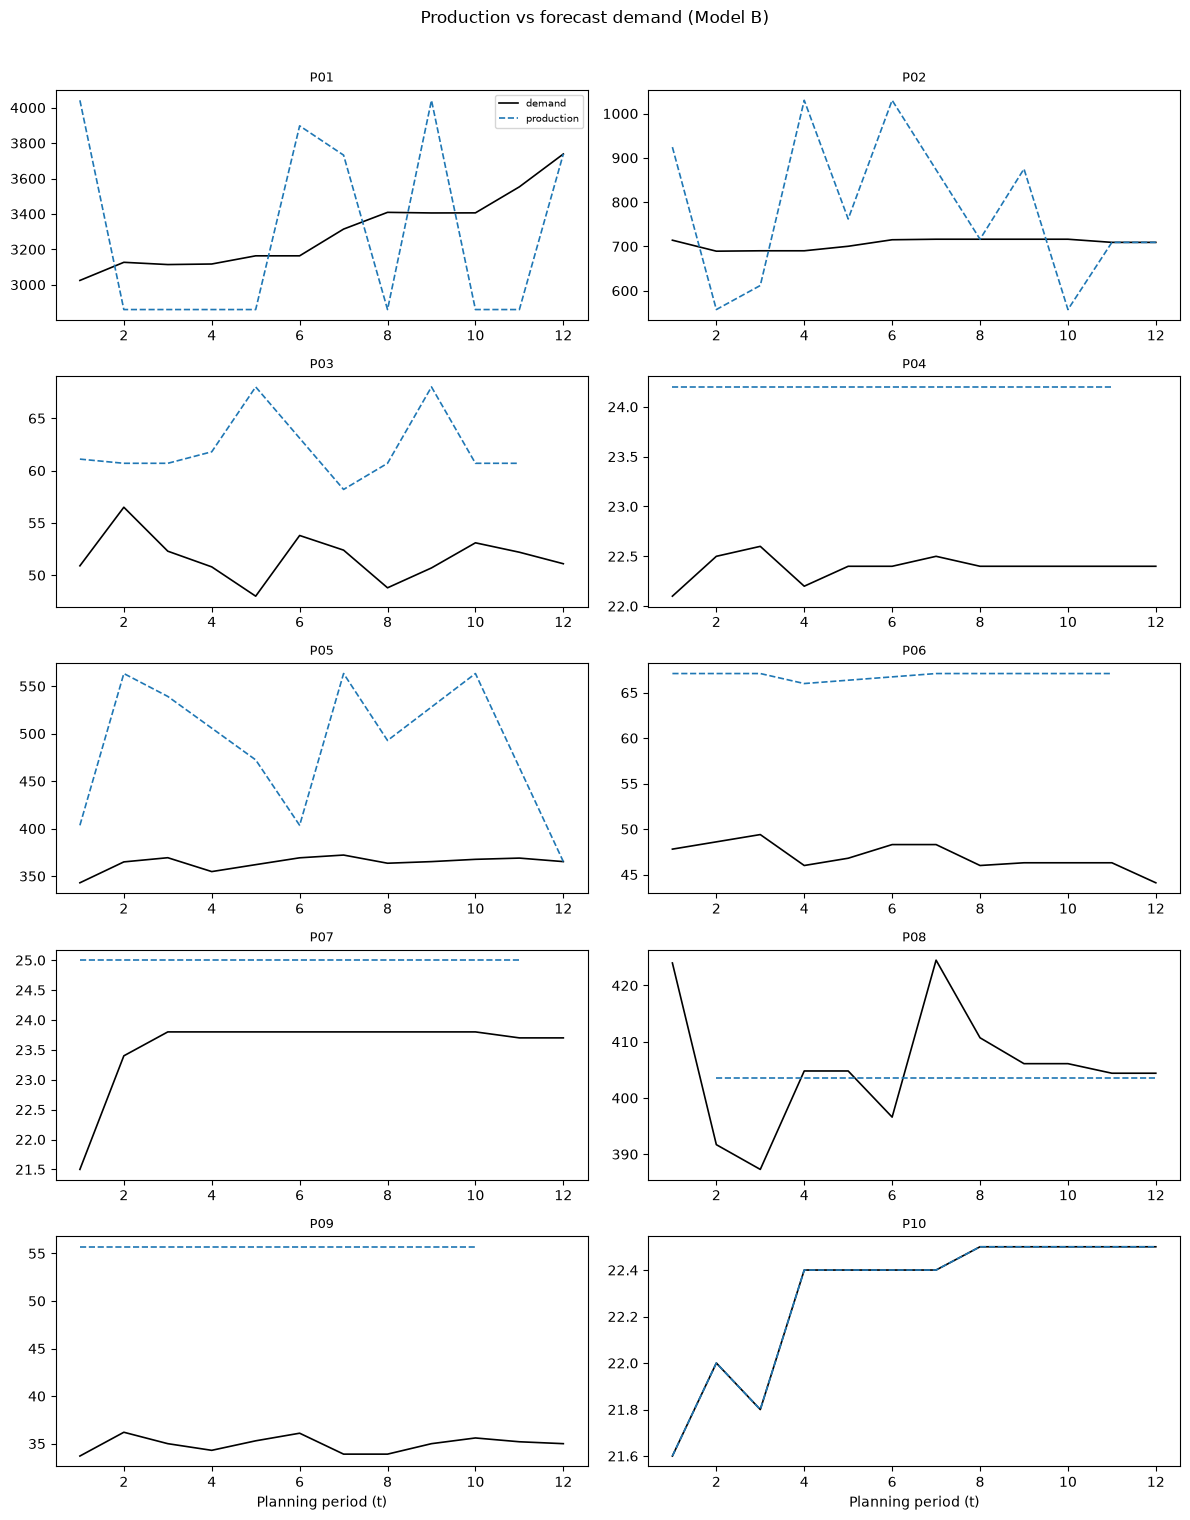

In [94]:
weekly_production = production_plan.groupby(["product_id", "t"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    dem = forecast[forecast["product_id"] == p].sort_values("t")
    prod = weekly_production[weekly_production["product_id"] == p]

    ax.plot(dem["t"], dem["forecast"], color="black", linewidth=1.2, label="demand")
    ax.plot(prod["t"], prod["quantity"], color="tab:blue", linestyle="--", linewidth=1.2, label="production")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Production vs forecast demand (Model B)", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: inventory trajectory, per product

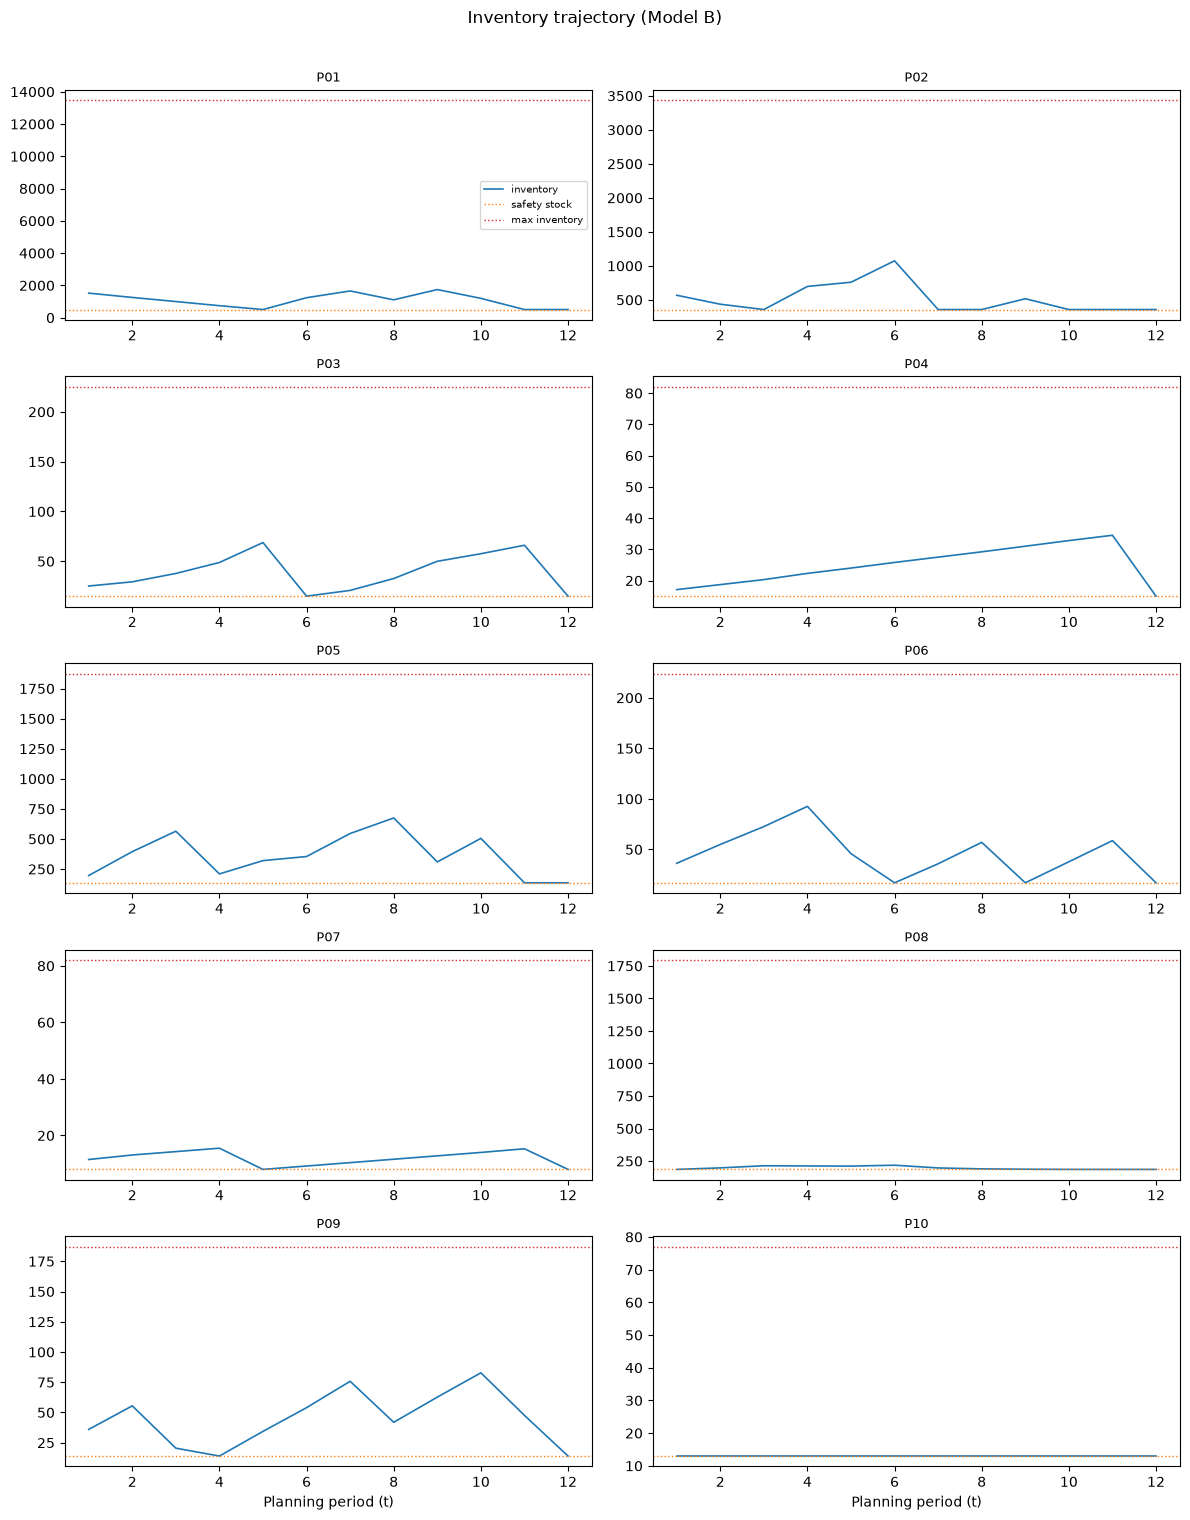

In [95]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    inv_series = inventory_plan[inventory_plan["product_id"] == p].sort_values("t")

    ax.plot(inv_series["t"], inv_series["inventory"], color="tab:blue", linewidth=1.2, label="inventory")
    ax.axhline(safety_stock[p], color="tab:orange", linestyle=":", linewidth=1, label="safety stock")
    ax.axhline(max_inventory[p], color="tab:red", linestyle=":", linewidth=1, label="max inventory")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Inventory trajectory (Model B)", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: machine utilization

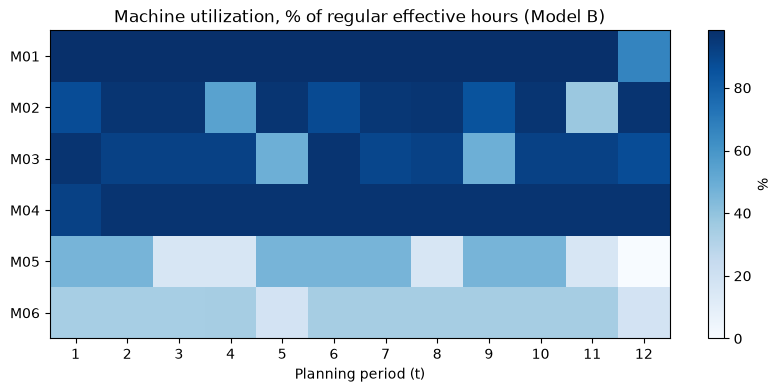

t,1,2,3,4,5,6,7,8,9,10,11,12
machine_id,,,,,,,,,,,,
M01,98.3,98.3,98.3,98.3,98.3,98.3,98.3,98.3,98.3,98.3,98.3,66.4
M02,87.5,96.0,96.1,54.2,96.0,88.3,95.4,96.1,84.9,96.0,37.3,96.7
M03,96.4,91.6,91.6,91.6,48.7,96.4,89.8,91.6,48.7,91.6,91.6,87.3
M04,91.6,96.4,96.4,96.4,96.4,96.4,96.4,96.4,96.4,96.4,96.4,96.4
M05,46.3,46.3,15.4,15.4,46.3,46.3,46.3,15.4,46.3,46.3,15.4,0.0
M06,33.8,34.1,34.0,34.4,17.8,34.4,34.4,34.5,34.5,34.5,34.5,17.9


In [96]:
used_hours = production_plan.groupby(["machine_id", "t"])["hours"].sum().reset_index()

util = pd.DataFrame([(m, t) for m in M for t in T], columns=["machine_id", "t"])
util = util.merge(used_hours, on=["machine_id", "t"], how="left").fillna({"hours": 0})
util["available_hours"] = util.apply(lambda r: available_hours[(r["machine_id"], r["t"])], axis=1)
util["utilization_pct"] = (util["hours"] / util["available_hours"] * 100).round(1)

pivot_util = util.pivot(index="machine_id", columns="t", values="utilization_pct").reindex(M)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_util.values, aspect="auto", cmap="Blues", vmin=0)
ax.set_yticks(range(len(pivot_util.index)))
ax.set_yticklabels(pivot_util.index)
ax.set_xticks(range(len(pivot_util.columns)))
ax.set_xticklabels(pivot_util.columns)
ax.set_xlabel("Planning period (t)")
ax.set_title("Machine utilization, % of regular effective hours (Model B)")
fig.colorbar(im, ax=ax, label="%")
plt.show()

pivot_util

## Visualization: setup count per machine per week

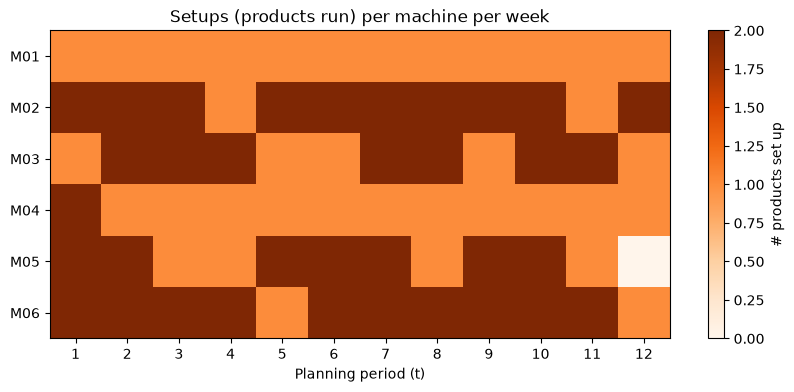

t,1,2,3,4,5,6,7,8,9,10,11,12
machine_id,,,,,,,,,,,,
M01,1,1,1,1,1,1,1,1,1,1,1,1
M02,2,2,2,1,2,2,2,2,2,2,1,2
M03,1,2,2,2,1,1,2,2,1,2,2,1
M04,2,1,1,1,1,1,1,1,1,1,1,1
M05,2,2,1,1,2,2,2,1,2,2,1,0
M06,2,2,2,2,1,2,2,2,2,2,2,1


In [97]:
setup_report["count"] = 1
setup_pivot = setup_report.pivot_table(index="machine_id", columns="t", values="count", aggfunc="sum", fill_value=0)
setup_pivot = setup_pivot.reindex(M, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(setup_pivot.values, aspect="auto", cmap="Oranges", vmin=0)
ax.set_yticks(range(len(setup_pivot.index)))
ax.set_yticklabels(setup_pivot.index)
ax.set_xticks(range(len(setup_pivot.columns)))
ax.set_xticklabels(setup_pivot.columns)
ax.set_xlabel("Planning period (t)")
ax.set_title("Setups (products run) per machine per week")
fig.colorbar(im, ax=ax, label="# products set up")
plt.show()

setup_pivot

## Compare against Model A

Load Model A's results, saved at the end of notebook 05, rather than rebuilding it here.
Same 12-week forecast, same factory, only difference is whether setup costs/times and
min-batch are modeled. Checking specifically: does M06 (idle in Model A) actually get used in
Model B, and does production shift toward primary machines (lower `setup_cost`)?

In [98]:
summary_a = pd.read_csv(RESULTS_DIR / "model_a_summary.csv")
cost_breakdown_a = pd.read_csv(RESULTS_DIR / "model_a_cost_breakdown.csv", index_col=0)
machine_usage_a = pd.read_csv(RESULTS_DIR / "model_a_machine_usage.csv", index_col=0)["total_hours"]

summary_a

,model,status,total_cost,solve_time_s
0,"Model A (LP, no setup)",2,72878.469,0.013108


In [99]:
cost_comparison = pd.DataFrame({
    "Model A (no setup)": cost_breakdown_a["cost"].reindex(["production", "holding", "overtime", "shortage"]).fillna(0),
    "Model B (with setup)": cost_breakdown_df["cost"].reindex(["production", "holding", "overtime", "shortage"]),
})
cost_comparison.loc["setup"] = [0.0, cost_breakdown_df["cost"].get("setup", 0.0)]
cost_comparison.loc["TOTAL"] = [summary_a["total_cost"].iloc[0], model.ObjVal]
cost_comparison.round(2)

,Model A (no setup),Model B (with setup)
production,72488.50,71884.92
holding,389.96,713.64
overtime,0.00,0.00
shortage,0.00,1218.10
setup,0.00,10470.00
TOTAL,72878.47,84286.66


In [100]:
usage_comparison = pd.DataFrame({
    "Model A total processing hours": machine_usage_a,
    "Model B total processing hours": machine_usage_b,
}).round(1)
usage_comparison

,Model A total processing hours,Model B total processing hours
machine_id,,
M01,698.4,667.9
M02,862.3,778.8
M03,480.1,425.7
M04,498.2,482.2
M05,325.4,242.9
M06,206.9,238.8
